## HALLAMOS LOS PLUVIOS MÁS CERCANOS A LOS EVENTOS DEL INVENTARIO
### - Calculamos los acumulados

In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
from funciones import *
from geopy.distance import geodesic
import os
import glob

#--------- CARGAMOS INVENTARIO -------------

inventario = pd.read_csv('/home/oisanchezp/Thesis/data/processed/inventario_unificado.csv')
pluvios = pd.read_csv('/home/oisanchezp/Thesis/data/metadata/pluviometros_metadatos_20250506.csv')

#%%
# Convertir las fechas a formato datetime
inventario['fecha_hora_evento'] = pd.to_datetime(inventario['fecha_hora_evento'])
pluvios['FechaInstalacion'] = pd.to_datetime(pluvios['FechaInstalacion'])

# Ruta a los datos horarios de los pluviómetros
ruta_datos_horarios = '/mnt/investigacion/geotecnia/Pluvios_horarios/Pluvios_horarios_completos/'

#Ruta donde se guardaran los últimos datos de los pluvios de manera provisional
#ruta_save = '../data/processed/pluvios_nuevos/'

# Ruta donde se guardaran los últimos datos de los pluvios Horarios de manera provisional
#output_path = '/mnt/investigacion/geotecnia/Pluvios_horarios/Pluvios_nuevos/'


#----------- Función para encontrar pluviómetro con datos válidos ----------
#---------------------------------------------------------------------------

def encontrar_pluviometro_con_datos(fecha_evento, lat_evento, lon_evento):
    # 1 Filtrar pluviómetros instalados antes del evento
    pluvios_filtrados = pluvios[pluvios['FechaInstalacion'] <= fecha_evento].copy()
    if pluvios_filtrados.empty:
        return None, [None]*97

    # 2 Distancia ≤ 5 km
    pluvios_filtrados['Distancia'] = pluvios_filtrados.apply(
        lambda r: geodesic(
            (lat_evento, lon_evento),
            (r['Latitude'], r['Longitude'])
        ).kilometers,
        axis=1
    )
    pluvios_filtrados = pluvios_filtrados[pluvios_filtrados['Distancia'] <= 5]
    if pluvios_filtrados.empty:
        return None, [None]*97

    # 3 Probar pluviómetros por cercanía
    for _, pluvio in pluvios_filtrados.sort_values('Distancia').iterrows():
        codigo = pluvio['Codigo']
        ruta = os.path.join(
            ruta_datos_horarios,
            f'H_Datos_Procesados_Est_{codigo}.csv'
        )
        if not os.path.exists(ruta):
            continue

        datos = pd.read_csv(ruta, parse_dates=['Fecha']).set_index('Fecha')

        # Intervalos
        inicio_97d = fecha_evento - pd.Timedelta(days=97)
        intervalo_97d = datos.loc[inicio_97d:fecha_evento]

        if intervalo_97d.empty:
            continue

        # --- Nueva verificación: últimos 7 días ---
        inicio_7d = fecha_evento - pd.Timedelta(days=6)   # día 0 incluido
        dias_con_datos = datos.loc[inicio_7d:fecha_evento]['P'].resample('D').count()
        if (dias_con_datos == 0).any():
            continue  # al menos un día sin datos ➜ probar siguiente pluvio
        # ------------------------------------------

        # Calcular acumulados 1‑97 días
        acumulados = []
        for d in range(1, 98):
            lluvia = datos.loc[fecha_evento - pd.Timedelta(days=d):fecha_evento]['P'].sum()
            acumulados.append(lluvia)

        return codigo, acumulados

    # Si ninguno sirve
    return None, [None]*97



#----------------- Crear nuevo DataFrame ----------------
#Crear una lista para almacenar los datos del nuevo DataFrame
datos_nuevo_df = []

# Iterar sobre cada evento en el inventario
for idx, evento in inventario.iterrows():
    print(f'Procesando evento {idx+1}/{len(inventario)}')
    codigo_pluviometro, acumulados_lluvia = encontrar_pluviometro_con_datos(evento['fecha_hora_evento'], evento['latitud'], evento['longitud'])
    
    # Crear un diccionario con los datos requeridos
    datos_evento = {
        'fecha_hora_evento': evento['fecha_hora_evento'],
        'incertidumbre_fecha': evento['incertidumbre_fecha'],
        'latitud': evento['latitud'],
        'longitud': evento['longitud'],
        'incertidumbre_ubicacion': evento['incertidumbre_ubicacion'],
        'tipo_movimiento_masa': evento['tipo_movimiento_masa'],
        'municipio' : evento['municipio'],
        'corregimiento' : evento['corregimiento'],
        'vereda_barrio': evento['vereda_barrio'],
        'Codigo': codigo_pluviometro,
        'si_no': 1  # Todos son deslizamientos, así que siempre es 1
    }

    # Agregar acumulados de lluvia al diccionario
    for i in range(1, 98):
        datos_evento[f'{i}d'] = acumulados_lluvia[i-1]
    datos_nuevo_df.append(datos_evento)

#%%
# Crear el nuevo DataFrame
nuevo_df = pd.DataFrame(datos_nuevo_df)

#%%
# Guardar el nuevo DataFrame a un archivo CSV
nuevo_df.to_csv('/home/oisanchezp/Thesis/data/processed/inventario_si_20251109.csv', index=False)

print("El nuevo DataFrame ha sido creado y guardado como 'nuevo_dataframe.csv'")


Procesando evento 1/496
Procesando evento 2/496
Procesando evento 3/496
Procesando evento 4/496
Procesando evento 5/496
Procesando evento 6/496
Procesando evento 7/496
Procesando evento 8/496
Procesando evento 9/496
Procesando evento 10/496
Procesando evento 11/496
Procesando evento 12/496
Procesando evento 13/496
Procesando evento 14/496
Procesando evento 15/496
Procesando evento 16/496
Procesando evento 17/496
Procesando evento 18/496
Procesando evento 19/496
Procesando evento 20/496
Procesando evento 21/496
Procesando evento 22/496
Procesando evento 23/496
Procesando evento 24/496
Procesando evento 25/496
Procesando evento 26/496
Procesando evento 27/496
Procesando evento 28/496
Procesando evento 29/496
Procesando evento 30/496
Procesando evento 31/496
Procesando evento 32/496
Procesando evento 33/496
Procesando evento 34/496
Procesando evento 35/496
Procesando evento 36/496
Procesando evento 37/496
Procesando evento 38/496
Procesando evento 39/496
Procesando evento 40/496
Procesand

## HALLAMOS EVENTOS DE LLUVIA ALEATORIOS ASOCIADOS A LA NO OCURRENCIA DE MOVIMIENTO EN MASA
### - Calculamos los acumulados
### - Luego concatenamos los si con los no

In [ ]:
import os
import numpy as np
import pandas as pd
from funciones import *
# --- Cargar metadatos ---
# inv = pd.read_csv('../data/metadata/inventario_20250506.csv',
#                   parse_dates=['fecha_hora_evento'])
inv = pd.read_csv('/home/oisanchezp/Thesis/data/processed/inventario_si_20251109.csv',
                  parse_dates=['fecha_hora_evento'])
pluvios = pd.read_csv('/home/oisanchezp/Thesis/data/metadata/pluviometros_metadatos_20250506.csv')
ruta = '/mnt/investigacion/geotecnia/Pluvios_horarios/Pluvios_horarios_completos/'

# --- 1. Fechas a excluir ±90 días ---
excluidas = pd.Index(
    np.unique(
        np.concatenate([
            pd.date_range(f - pd.Timedelta(days=30),
                          f + pd.Timedelta(days=30),
                          freq='D').date
            for f in inv['fecha_hora_evento'].dt.normalize()
        ])
    )
)


# --- 2. Pre-cargar cada pluviómetro una sola vez ---
candidatos, series_acum = [], {}
H24, H90 = 24, 24*90                # pasos de 1 día y 90 días en horas

for _, p in pluvios.iterrows():
    cod = p['Codigo']
    fn  = f'H_Datos_Procesados_Est_{cod}.csv'
    path = os.path.join(ruta, fn)
    if not os.path.exists(path):
        continue

    df = pd.read_csv(path, usecols=['Fecha', 'P'], parse_dates=['Fecha'])

    serie_h = (df.groupby('Fecha')['P'].sum()
                .sort_index()
                .asfreq('H', fill_value=0))     # índice horario regular sin duplicados

    cs = serie_h.cumsum().astype(np.float32)
    series_acum[cod] = cs

    idx = cs.index
    mask = ~idx.isin(excluidas)                # fuera de ventanas ±90 días

    # lluvias 1 d y 90 d vectorizadas
    lluvia1d  = cs - cs.shift(H24)
    lluvia90d = cs - cs.shift(H90)
    lluviosos = (lluvia1d >= 5) & (lluvia90d >= 100)

    fechas_ok = idx[mask & lluviosos]
    candidatos.extend(
        [(f, cod) for f in fechas_ok]
    )

# --- 3. Muestreo balanceado ---
n_si   = len(inv)
rng    = np.random.default_rng(42)
muestras = rng.choice(candidatos, size=n_si, replace=False)

# --- 4. Construir DataFrame NO-evento con acumulados 1-97 días ---
dias   = np.arange(1, 98, dtype=int)
filas  = []

for fecha, cod in muestras:
    cs = series_acum[cod]
    pos = cs.index.get_loc(fecha)
    # array con acumulados de 1-97 días (24 h × d)
    vals = cs.iloc[pos] - cs.iloc[pos - dias*H24].values
    fila = {'fecha_hora_evento': fecha,
            'Codigo': cod,
            'si_no': 0,
            **{f'{d}d': vals[d-1] for d in dias}}
    filas.append(fila)

df_no = pd.DataFrame(filas)


df_si = pd.read_csv('/home/oisanchezp/Thesis/data/processed/inventario_unificado.csv')


# df_si = df_si[
#     (df_si["1d"] > 10)  &
#     (df_si["91d"] >= 300)  &
#     (df_si['7d'] > 40)  
# ]

df_no = df_no[
    (df_no["1d"] >= 5)  &
    (df_no["91d"] >= 100)  &
    (df_no['7d'] >= 10)  
]

print(f"Eventos: {len(df_si)}")
print(f"No eventos: {len(df_no)}")

# Número de filas en df_si
n_filas_si = len(df_si)

# Seleccionar aleatoriamente n_filas_si filas de df_no
df_no_sampled = df_no.sample(n=n_filas_si, random_state=42)

# Unir los dos dataframes
df_combined = pd.concat([df_si, df_no_sampled], axis=0, ignore_index=True)

#%%
# Guardar el nuevo DataFrame a un archivo CSV
df_combined.to_csv('/home/oisanchezp/Thesis/data/processed/inventario_si_no_20251109.csv', index=False)

Eventos: 496
No eventos: 480


ValueError: Cannot take a larger sample than population when 'replace=False'

In [3]:
import os
import numpy as np
import pandas as pd

# -------------------------
# Entradas
# -------------------------
inv_path      = '/home/oisanchezp/Thesis/data/processed/inventario_si_20251109.csv'   # eventos SÍ
pluv_meta     = '/home/oisanchezp/Thesis/data/metadata/pluviometros_metadatos_20250506.csv'
ruta_series   = '/mnt/investigacion/geotecnia/Pluvios_horarios/Pluvios_horarios_completos/'
out_path      = '/home/oisanchezp/Thesis/data/processed/inventario_si_no_20251109.csv'
seed          = 42

# Umbrales
UMBRAL_1D  = 5
UMBRAL_7D  = 10
UMBRAL_91D = 100

# ventanas en horas
H1   = 24
H7   = 7 * 24
H91  = 91 * 24

# -------------------------
# 1) Cargar inventario SÍ y días excluidos ±30
# -------------------------
inv = pd.read_csv(inv_path, parse_dates=['fecha_hora_evento'])

# Asegura que inv sólo tenga eventos SÍ (si tu CSV ya viene filtrado, esto no cambia nada)
if 'si_no' in inv.columns:
    inv = inv[inv['si_no'] == 1].copy()

# Días a excluir (por día) ±30
excluidas = pd.Index(
    np.unique(
        np.concatenate([
            pd.date_range(d.normalize() - pd.Timedelta(days=30),
                          d.normalize() + pd.Timedelta(days=30),
                          freq='D').date
            for d in inv['fecha_hora_evento']
        ])
    )
)

# -------------------------
# 2) Precargar series y armar candidatos
# -------------------------
pluvios = pd.read_csv(pluv_meta)
candidatos = []
series_acum = {}   # guarda cumsum por código para reutilizar

rng = np.random.default_rng(seed)

for _, p in pluvios.iterrows():
    cod = p['Codigo']
    fn  = f'H_Datos_Procesados_Est_{cod}.csv'
    path = os.path.join(ruta_series, fn)
    if not os.path.exists(path):
        continue

    # Lee serie (una fila por hora; si hay duplicados por hora, agrupa)
    df = pd.read_csv(path, usecols=['Fecha', 'P'], parse_dates=['Fecha'])
    serie_h = (df.groupby('Fecha')['P'].sum()
                 .sort_index()
                 .asfreq('H', fill_value=0))
    
    # Cumulada para diferencias rápidas
    cs = serie_h.cumsum().astype(np.float32)
    series_acum[cod] = cs

    idx = cs.index

    # Lluvias acumuladas 1d, 7d, 91d
    ll_1d  = cs - cs.shift(H1)
    ll_7d  = cs - cs.shift(H7)
    ll_91d = cs - cs.shift(H91)

    # Fuera de ventanas excluidas, comparando por DÍA
    fuera_ventanas = ~idx.normalize().isin(excluidas)

    # Candidatos que cumplen umbrales
    mask_ok = (fuera_ventanas &
               (ll_1d >= UMBRAL_1D) &
               (ll_7d >= UMBRAL_7D) &
               (ll_91d >= UMBRAL_91D))

    fechas_ok = idx[mask_ok]
    if len(fechas_ok):
        # Guardar (timestamp, código) como candidatos
        candidatos.extend([(f, cod) for f in fechas_ok])

# Quitar duplicados si los hubiera (mismo timestamp+código)
candidatos = list({(f, c) for (f, c) in candidatos})

# -------------------------
# 3) Muestreo: 2× eventos SÍ
# -------------------------
n_si = len(inv)
n_no_target = 2 * n_si

if len(candidatos) < n_no_target:
    raise ValueError(
        f"No hay suficientes candidatos que cumplan umbrales y ventanas: "
        f"necesitas {n_no_target}, hay {len(candidatos)}."
    )

muestras = rng.choice(candidatos, size=n_no_target, replace=False)

# -------------------------
# 4) Construir NO-eventos con acumulados
# -------------------------
dias = np.arange(1, 98, dtype=int)  # 1–97 días
filas = []

for fecha, cod in muestras:
    cs = series_acum[cod]
    # Si la fecha exacta no está (p. ej., por cortes), busca la hora previa más cercana
    if fecha not in cs.index:
        # get_loc con method='pad' toma la etiqueta previa
        pos = cs.index.get_loc(fecha, method='pad')
    else:
        pos = cs.index.get_loc(fecha)
    # Evita underflow al inicio de la serie
    if pos < dias[-1]*H1:
        continue

    vals = cs.iloc[pos] - cs.iloc[pos - dias*H1].values
    fila = {
        'fecha_hora_evento': pd.Timestamp(fecha),
        'Codigo': cod,
        'si_no': 0,
        **{f'{d}d': float(vals[d-1]) for d in dias}
    }
    filas.append(fila)

df_no = pd.DataFrame(filas)

# Reaplica filtro de umbrales por si alguna fecha cayó al inicio de serie
df_no = df_no[
    (df_no['1d']  >= UMBRAL_1D) &
    (df_no['7d']  >= UMBRAL_7D) &
    (df_no['91d'] >= UMBRAL_91D)
].copy()

# Si tras la verificación hay más de lo necesario, recorta aleatoriamente al objetivo
if len(df_no) > n_no_target:
    df_no = df_no.sample(n=n_no_target, random_state=seed)

# -------------------------
# 5) Preparar df_si y unir
# -------------------------
df_si = inv.copy()
if 'si_no' not in df_si.columns:
    df_si['si_no'] = 1

# (Opcional) si quieres quedarte sólo con algunas columnas en df_si, añade aquí

df_combined = pd.concat([df_si, df_no], axis=0, ignore_index=True)

# -------------------------
# 6) Salida
# -------------------------
df_combined.to_csv(out_path, index=False)

print(f"Eventos SÍ: {len(df_si)}  |  NO-eventos: {len(df_no)}  |  Total: {len(df_combined)}")
print(f"Guardado en: {out_path}")


Eventos SÍ: 496  |  NO-eventos: 989  |  Total: 1485
Guardado en: /home/oisanchezp/Thesis/data/processed/inventario_si_no_20251109.csv


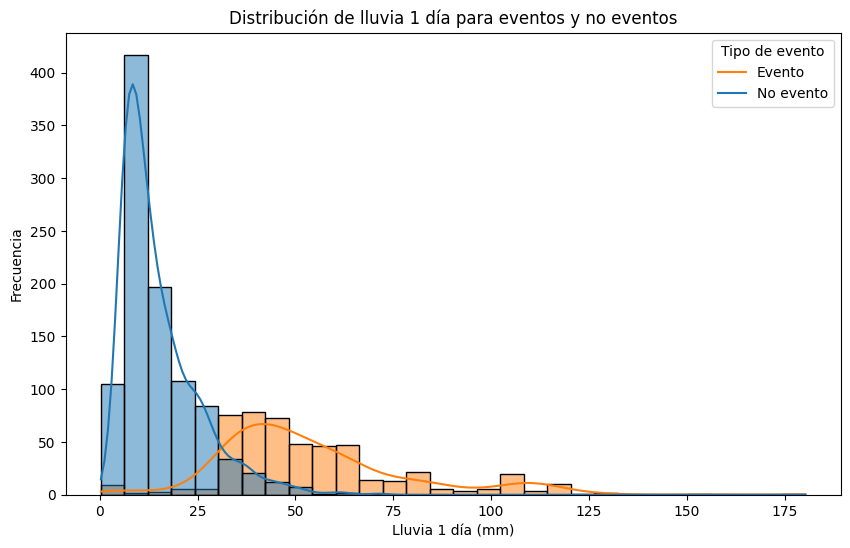

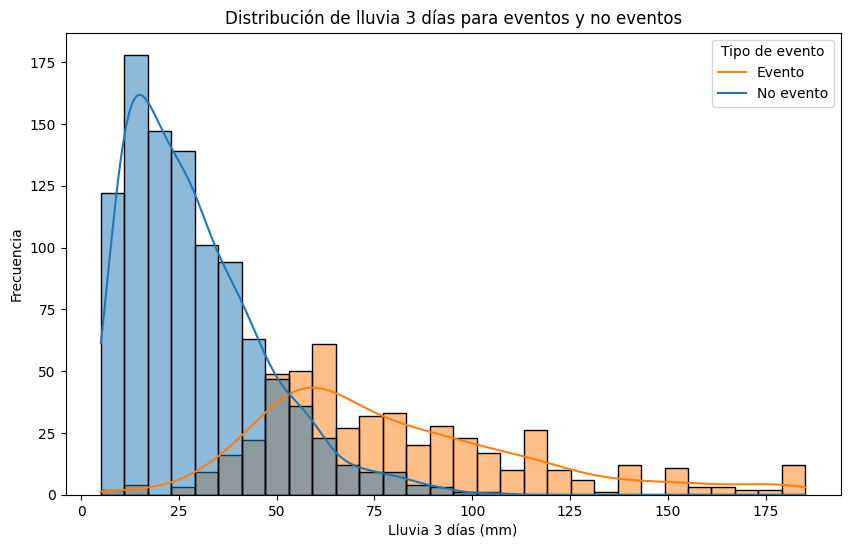

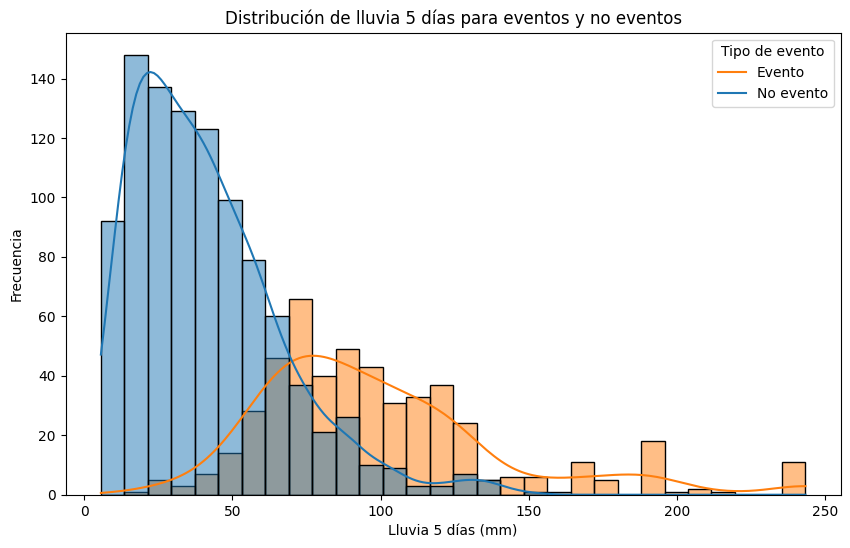

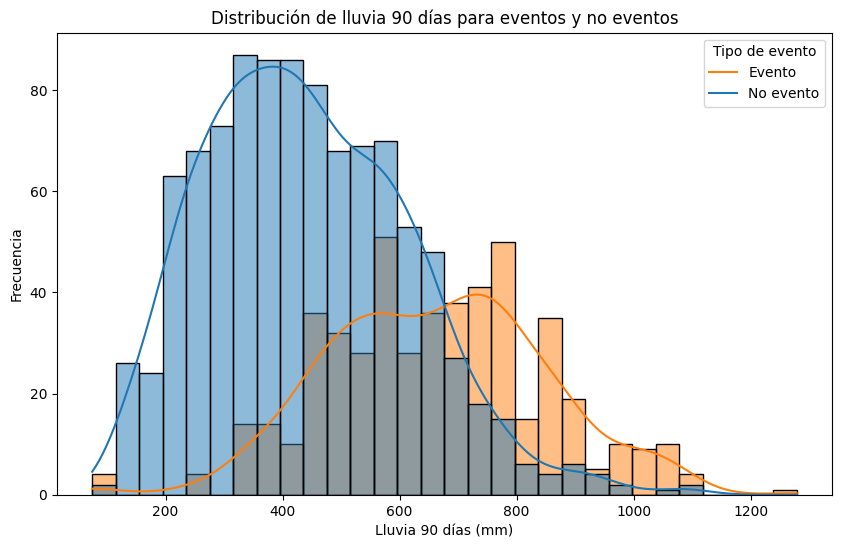

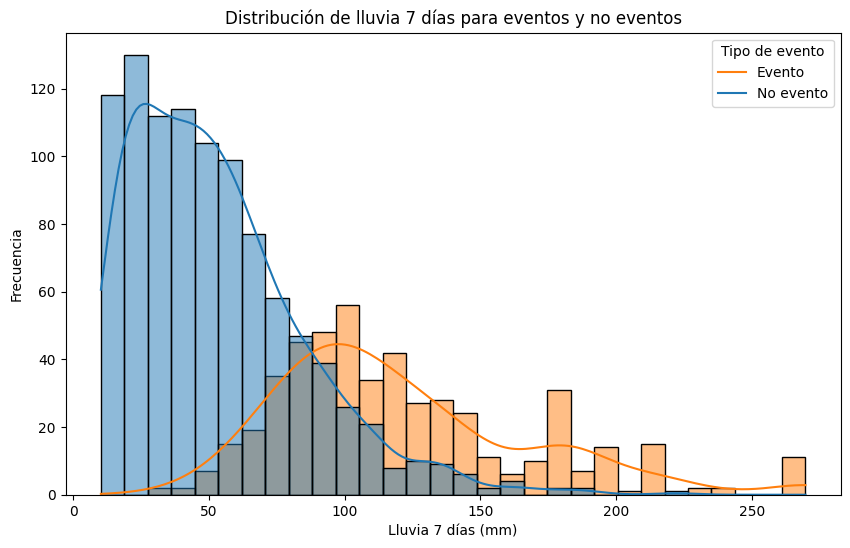

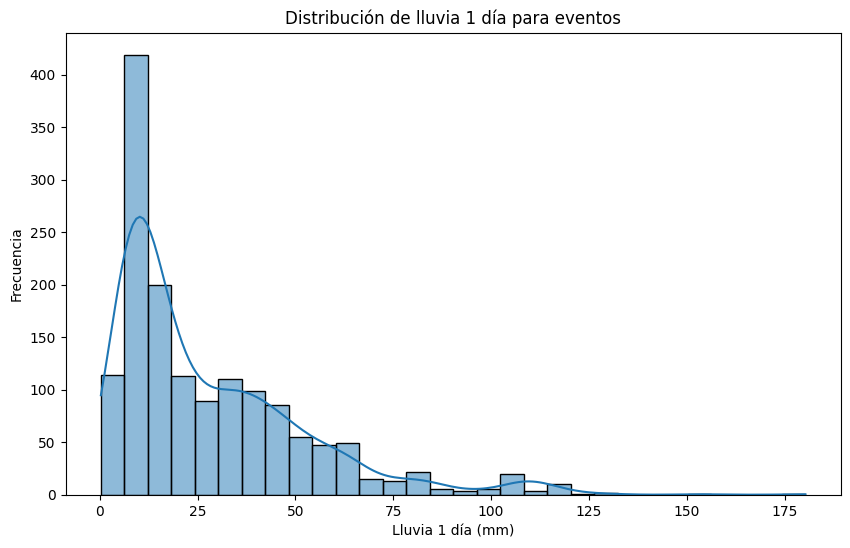

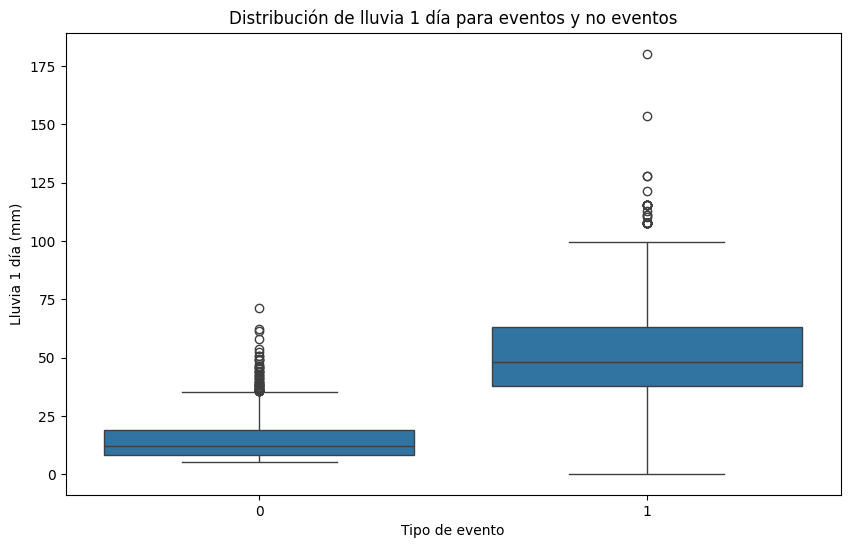

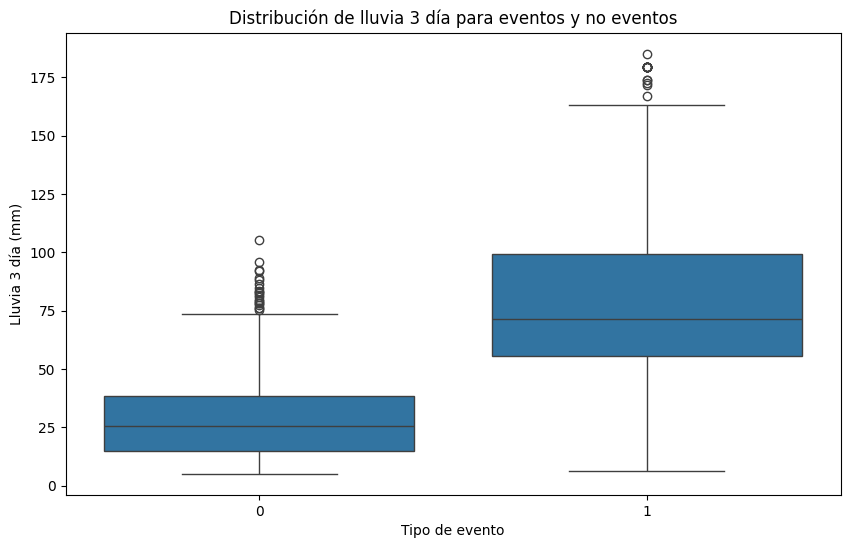

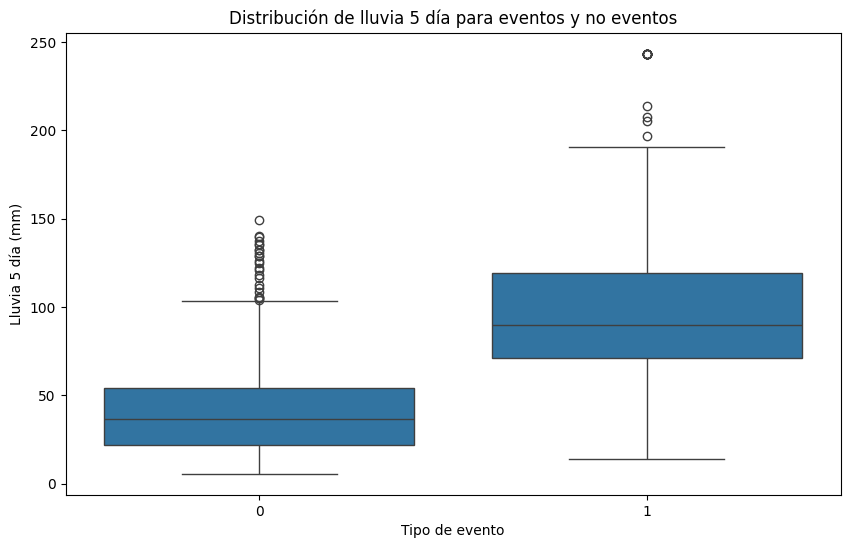

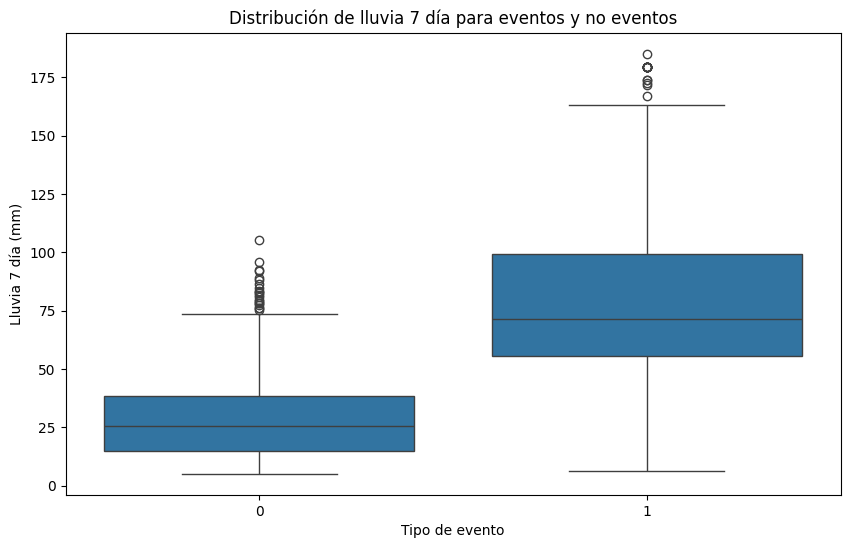

In [5]:
import matplotlib.pyplot as plt
df_combined = pd.read_csv('/home/oisanchezp/Thesis/data/processed/inventario_si_no_20251109.csv')
df_si = pd.read_csv('/home/oisanchezp/Thesis/data/processed/inventario_si_no_20251109.csv')
#hacer un grafico de la lluvia de 1 día para los eventos y no eventos
plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='1d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 1 día para eventos y no eventos')
plt.xlabel('Lluvia 1 día (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='3d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 3 días para eventos y no eventos')
plt.xlabel('Lluvia 3 días (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_7d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='5d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 5 días para eventos y no eventos')
plt.xlabel('Lluvia 5 días (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_7d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

#Hacer un grafico de la lluvia de 90 días para los eventos y no eventos
plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='91d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 90 días para eventos y no eventos')
plt.xlabel('Lluvia 90 días (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_90d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

#hacer un grafico de la lluvia de 7 días para los eventos y no eventos
plt.figure(figsize=(10, 6))
sns.histplot(df_combined, x='7d', hue='si_no', bins=30, kde=True)
plt.title('Distribución de lluvia 7 días para eventos y no eventos')
plt.xlabel('Lluvia 7 días (mm)')
plt.ylabel('Frecuencia')
plt.legend(title='Tipo de evento', labels=['Evento', 'No evento'])
#plt.savefig('../figures/lluvia_7d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()


#Hacer un grafico con los eventos para solos los que tiene si_no = 1
plt.figure(figsize=(10, 6))
sns.histplot(df_si, x='1d', bins=30, kde=True)
plt.title('Distribución de lluvia 1 día para eventos')
plt.xlabel('Lluvia 1 día (mm)')
plt.ylabel('Frecuencia')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

#hacer un bloxplot de la lluvia de 1 día para los eventos y no eventos
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='si_no', y='1d')
plt.title('Distribución de lluvia 1 día para eventos y no eventos')
plt.xlabel('Tipo de evento')
plt.ylabel('Lluvia 1 día (mm)')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='si_no', y='3d')
plt.title('Distribución de lluvia 3 día para eventos y no eventos')
plt.xlabel('Tipo de evento')
plt.ylabel('Lluvia 3 día (mm)')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='si_no', y='5d')
plt.title('Distribución de lluvia 5 día para eventos y no eventos')
plt.xlabel('Tipo de evento')
plt.ylabel('Lluvia 5 día (mm)')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='si_no', y='3d')
plt.title('Distribución de lluvia 7 día para eventos y no eventos')
plt.xlabel('Tipo de evento')
plt.ylabel('Lluvia 7 día (mm)')
#plt.savefig('../figures/lluvia_1d_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

## SACAMOS LOS UMBRALES Y COFECIENTES CON REGRESIÓN LOGISTICA PARA:
- 1 día vs. 90 días
- 3 días vs. 90 días
- 5 días vs. 90 días
- 7 días vs. 90 días

In [2]:
import os
import numpy as np
import pandas as pd
from funciones import *

sub = pd.read_csv('/home/oisanchezp/Thesis/data/processed/slope_units_si_no_20251115.csv')
#eliminar valores donde 90d o 7d sean nan
sub = sub.dropna(subset=['33d', '1d'])

#%%
dia_ref = 1
dia_ant = 33

ruta_results = '/home/oisanchezp/Thesis/results/03_Chapter'

X = pd.DataFrame()

X[str(dia_ant)+'d'] = sub[str(dia_ant + dia_ref)+'d'] - sub[str(dia_ref)+'d']
X[str(dia_ref)+'d'] = sub[str(dia_ref)+'d']

#%%
# Cargar datos
#X = sub[['91d','1d']]  # Variables predictoras
y = sub['si_no']             # Variable de respuesta

valor_x, valor_y = '33', '1'

#grafica_umbral_ROC(X, y, valor_x, valor_y, ruta_results)

#%%
grafica_probabilidad_v2(sub, X, y, valor_y, valor_x, ruta_results)
#grafica_probabilidad(sub, X,y, valor_y, valor_x, ruta_results)
#regresion_logistica_siammo(X,y, valor_y, valor_x, ruta_results)

/home/oisanchezp/geo_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/oisanchezp/geo_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/home/oisanchezp/geo_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


In [6]:
import pandas as pd
from funciones import *
sub = pd.read_csv('/home/oisanchezp/Thesis/data/processed/inventario_si_no_20251109.csv')

sub = sub.dropna(subset=['90d', '7d'])

#%%
dia_ref = 7
dia_ant = 90

ruta_results = '/home/oisanchezp/Thesis/results/03_Chapter/'
y = sub['si_no']             # Variable de respuesta

valor_x, valor_y = '90', '7'

X = pd.DataFrame()
X[str(dia_ant)+'d'] = sub[str(dia_ant + dia_ref)+'d'] - sub[str(dia_ref)+'d']
X[str(dia_ref)+'d'] = sub[str(dia_ref)+'d']

#grafica_umbral_ROC(X, y, valor_x, valor_y, ruta_results)
#grafica_probabilidad(sub, X,y, valor_y, valor_x, ruta_results)
grafica_probabilidad_v2(sub, X, y, valor_y, valor_x, ruta_results)
#grafica_probabilidad(sub, X,y, valor_y, valor_x, ruta_results)
#regresion_logistica_siammo(X,y, valor_y, valor_x, ruta_results)

/home/oisanchezp/geo_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/oisanchezp/geo_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/home/oisanchezp/geo_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


In [ ]:
#============================================================================
'''
    Evalua linea de decisión con Regresión Lineal, Support Vector Machine y
    Analisis Lineal Discriminante para las combinaciones de días:
    
    1 vs. 15, 1 vs. 30, 1 vs. 60, 1 vs. 90
    3 vs. 15, 3 vs. 30, 3 vs. 60, 3 vs. 90
    5 vs. 15, 5 vs. 30, 5 vs. 60, 5 vs. 90

'''
#============================================================================

sub = pd.read_csv(ruta_results+'sub.csv')

metrics = {}

dias = [1,3,5,7]
dias_antecedentes = [15,30,60,90]

for i in dias:
    print('Haciendo día: '+str(i))
    for j in dias_antecedentes:
        print('Haciendo: '+str(i)+'dvs.'+str(j)+'d')

        X = sub[[str(i)+'dvs.'+str(j)+'d', str(i)+'d']]
        y = sub['si_no']

        metrica_sub = metricas_umbrales(X, y)

        metrics[str(i)+'dvs.'+str(j)+'d'] = metrica_sub

#%%
#Guardamos metricas en .pkl
with open(ruta_results+'metricas_pluvios.pkl', 'wb') as f:
    pickle.dump(metrics, f)
# %%

f=open(ruta_results+'metricas_pluvios.pkl','rb')
metricas = pickle.load(f)

#%%
######GUARDAMOS EN UNA SOLA TABLA TODAS LAS METRICAS
rl = []
svm = []
ald = []
for i in metricas.keys():
    p = metricas[i]['Regresión Logística']['accuracy']
    o = metricas[i]['SVM']['accuracy']
    q = metricas[i]['LDA']['accuracy']
    rl.append(p)
    svm.append(o)
    ald.append(q)

rl_f1 = []
svm_f1 = []
ald_f1 = []

for i in metricas.keys():
    p = metricas[i]['Regresión Logística']['accuracy']
    o = metricas[i]['SVM']['accuracy']
    q = metricas[i]['LDA']['accuracy']
    rl_f1.append(p)
    svm_f1.append(o)
    ald_f1.append(q)

data = {
    ("Regresión Logística", "accuracy"): np.around(np.array(rl)*100, decimals=2),
    ("Regresión Logística", "f1-score"): np.around(np.array(rl_f1)*100, decimals=2),
    ("SVM", "accuracy"): np.around(np.array(svm)*100, decimals=2),
    ("SVM","f1-score"): np.around(np.array(svm_f1)*100, decimals=2),
    ("LDA", "accuracy"): np.around(np.array(ald)*100, decimals=2),
    ("LDA", "f1-score"): np.around(np.array(ald_f1)*100, decimals=2)
}

indices = ['1dvs.15d', '1dvs.30d', '1dvs.60d', '1dvs.90d', '3dvs.15d', '3dvs.30d', '3dvs.60d', '3dvs.90d','5dvs.15d', '5dvs.30d', '5dvs.60d', '5dvs.90d', 
           '7dvs.15d', '7dvs.30d', '7dvs.60d','7dvs.90d'] 

a = pd.DataFrame(data, index= indices)
a.index.name = 'LA vs. LAA'
#%%
a.to_csv(ruta_results+ 'metricas_pluvios.csv')